# Proyecto con Empresa Aliada Parte 6 - Pronóstico de ventas de Vanish y Lysol

Durante esta parte del proyecto, será desarrollado un modelo predictivo para prever las ventas futuras de las marcas clave de Reckitt: Vanish y Lysol.

Dada la naturaleza de los datos analizados en el transcurso de este proyecto, lo mejor es utilizar un modelo de análisis de series de tiempo, ya que las únicas variables numéricas son los propios datos de ventas unitarias, monetarias y los promedios históricos. Esto implica que aplicar un modelo de regresión no sería el mejor acercamiento a este problema. 

El modelo que será aplicado para analizar la serie de tiempo es el modelo ARIMA(p, d, q), el cual consiste en descomponer una variable en función de sus valores pasados para proyectar tendencias futuras.

Los parámetros centrales definen su estructura: 
- **p (Orden Autorregresivo - AR)**: Indica el número de valores pasados (retrasos/lags) de la propia variable que influyen en el valor actual. 
- **d (Grado de Integración - I)**: Representa el número de diferencias necesarias para hacer que la serie sea estacionaria (que su media y varianza sean constantes en el tiempo). 
- **q (Orden de Media Móvil - MA)**: Mide el número de errores de predicción pasados (ruido blanco) que se utilizan para predecir los valores futuros utilizando promedios móviles.


## Carga de los datos con las ventas históricas

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore') # Para evitar Warnings innecesarios
sns.set_style('darkgrid') # Establecemos el estilo de las gráficas para que se vena más profesionales

df = pd.read_csv('Final_DataFrame.csv', index_col=0)
df.head()

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,MANUFACTURER,BRAND,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENT
0,2022-08-28,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
1,2022-08-28,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
2,2022-08-28,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
3,2022-08-28,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
4,2022-08-28,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,FABRIC TREATMENT and SANIT,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 122002 entries, 0 to 122001
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   WEEK                         122002 non-null  object 
 1   ITEM_CODE                    122002 non-null  object 
 2   TOTAL_UNIT_SALES             122002 non-null  float64
 3   TOTAL_VALUE_SALES            122002 non-null  float64
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64
 5   REGION                       122002 non-null  object 
 6   MANUFACTURER                 122002 non-null  object 
 7   BRAND                        122002 non-null  object 
 8   ITEM_DESCRIPTION             122002 non-null  object 
 9   CATEGORY                     122002 non-null  object 
 10  FORMAT                       122002 non-null  object 
 11  ATTR1                        122002 non-null  object 
 12  ATTR2                        122002 non-null  object 
 13 

Falta convertir la columna de "WEEK" a un tipo que almacene fechas (datetime)

In [13]:
df['WEEK'] = pd.to_datetime(df['WEEK'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 122002 entries, 0 to 122001
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   WEEK                         122002 non-null  datetime64[ns]
 1   ITEM_CODE                    122002 non-null  object        
 2   TOTAL_UNIT_SALES             122002 non-null  float64       
 3   TOTAL_VALUE_SALES            122002 non-null  float64       
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64       
 5   REGION                       122002 non-null  object        
 6   MANUFACTURER                 122002 non-null  object        
 7   BRAND                        122002 non-null  object        
 8   ITEM_DESCRIPTION             122002 non-null  object        
 9   CATEGORY                     122002 non-null  object        
 10  FORMAT                       122002 non-null  object        
 11  ATTR1                     

Solo filtraremos los datos que nos interesan predecir, es decir, aquellas ventas de Vanish y Lysol

In [14]:
# Filtrando solamente las marcas de interés
sales = df[(df['BRAND'] == 'VANISH') | (df['BRAND'] == 'LYSOL')]

# COmprobando que el filtro se haya aplicado correctamente
print('Las únicas marcas presentes en el nuevo DataFrame es:', sales['BRAND'].unique())

Las únicas marcas presentes en el nuevo DataFrame es: ['VANISH' 'LYSOL']


Los datos de ventas están desglosados por producto en las diferentes semanas registradas, por lo que se agruparán los datos de ventas por semana y se sumarán las ventas unitarias totales (columna ['TOTAL_UNIT_SALES']) en cada grupo.

In [15]:
# Agrupando las ventas por semana y aplicando la función de agregación de suma por cada grupo 
sales = sales.groupby(by='WEEK').sum()['TOTAL_UNIT_SALES'] # SOlo se tomará en cuenta los valores de las ventas unitarias, de la columna: 'TOTAL_UNIT_SALES'

sales

WEEK
2022-01-09    734.571
2022-01-16    698.395
2022-01-23    597.321
2022-01-30    597.483
2022-02-06    635.299
               ...   
2023-06-19    737.902
2023-06-26    720.985
2023-07-03    787.791
2023-07-10    794.248
2023-07-17    729.384
Name: TOTAL_UNIT_SALES, Length: 80, dtype: float64

## Gráfica de las ventas unitarias de Vanish y Lysol

Antes de aplicar el modelo ARIMA a estos datos, vamos a visualizarlos previamente:

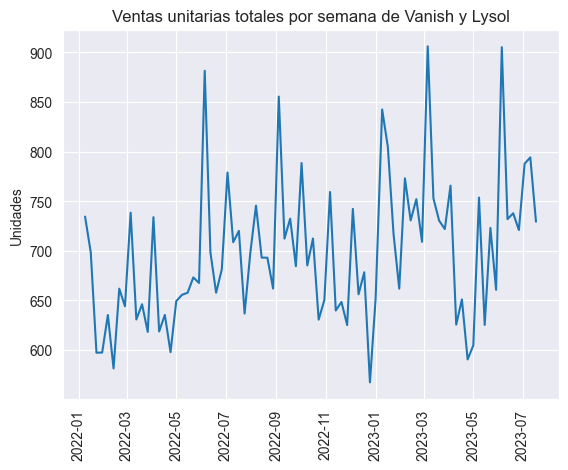

In [16]:
plt.plot(sales.index, sales.values)
plt.xticks(rotation=90)
plt.title('Ventas unitarias totales por semana de Vanish y Lysol')
plt.ylabel('Unidades')
plt.show()

Podemos ver de la gráfica que las ventas abarcan desde enero de 2022 hasta julio de 2023. Las ventas totales de ambas marcas tienen fluctuaciones muy marcadas, pero tienen una tendencia casi constante vista desde este rango de fechas. Encontrar estos patrones y replicarlos será el objetivo de ajustar el modelo ARIMA.

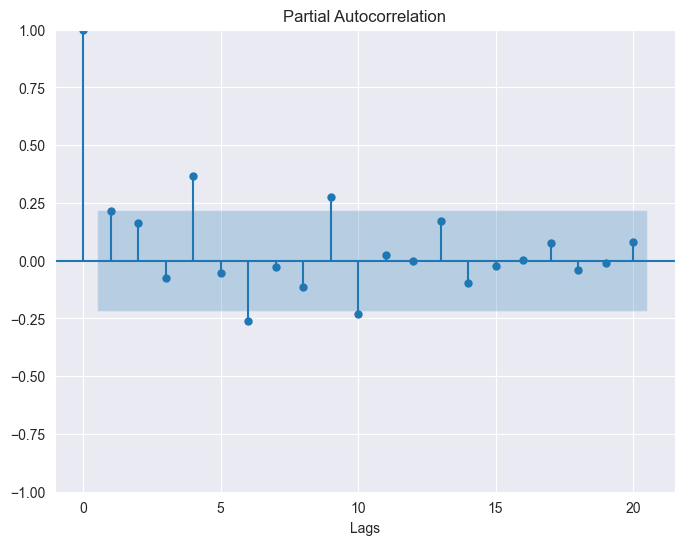

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,1, figsize=(8,6))

# Graficación de la función de autocorrelación parcial (PACF)
plot_pacf(sales, lags=20, ax = ax, alpha=0.05)

plt.xlabel('Lags')
plt.show()

Podemos observar que el pico más grande se encuentra en lags=4 (Descartando el 0 trivial). Esto nos indica que muy probablemente el mejor modelo que se encuentre cuente con p=4. Aún así eso lo comprobaremos probando múltiples modelos.

Separaremos primero los datos en conjuntos de entrenamiento y prueba, tomando el primer 90% de los datos:


In [18]:
# Definición de grupos de prueba y entrenamiento
len_train = int(len(sales)*0.9) 
sales_train = sales[:len_train] # Asignando al conjunto de entrenamiento el 90% de los primeros datos
sales_test = sales[len_train:]

Para aplicar el modelo ARIMA correctamente, es esencial primero revisar si la serie de tiempo es estacionaria o no. Para ello, se aplicará la prueba de Dickey-Fuller:

In [19]:
from statsmodels.tsa.stattools import adfuller

# Realización de la pruba Dickey-Fuller
# H0: La serie es NO ESTACIONARIA
# Ha: La serie es ESTACIONARIA

result = adfuller(sales_train.values)
print('El valor p de la prueba de Dickey-Fuller para las ventas es:', result[1])

El valor p de la prueba de Dickey-Fuller para las ventas es: 0.08405475836693599


**Como el valor es mayor a 0.05, no hay evidencia estadística para rechazar $H_0$ (indicando que las series NO es estacionaria).**

Dado que no pasó la prueba de Dickey-Fuller, es recomendable transformar la serie de tiempo a una serie que SÍ sea estacionaria. La técnica más recomendada para esto es sacar diferencias consecutivas

In [20]:
sales_diffs = sales_train.diff().dropna() # Aplicando primeras diferencias y eliminando diferencias imposibles de calcular
# Aplicación de la prueba Dickey-Fuller sobre las diferencias
result = adfuller(sales_diffs)
print('El valor p de la prueba de Dickey-Fuller para las differencias de ventas es:', result[1])

El valor p de la prueba de Dickey-Fuller para las differencias de ventas es: 0.010627462708412791


### Conclusión: La serie transformada de primeras diferencias (d=1) ahora SÍ ES ESTACIONARIA

## Probando múltiples modelos ARIMA

Para ver cuáles serían los parámetros más óptimos, se tendrán que ver múltiples combinaciones de p, d y q para probar modelos ARIMA(p,d,q). Afortunadamente, ya pudimos fijar d=1 con el análisis anterior, por lo que solo hay que probar combinaciones de p y q.

Cada modelo será evaluado a través de su Akaike Information Criterion (AIC). El mejor modelo será aquel que tenga el menor AIC, pues significa que este consigue la mayor precisión y el menor sobreajuste. Por lo tanto, el DataFrame donde se guarden los resultados se ordenará de forma ascendente según su AIC, ordenando los modelos del mejor al peor.

In [21]:
# Imporación del módulo para estimar un modelo ARIMA
from statsmodels.tsa.arima.model import ARIMA
# Importación de herramienta iterativa para probar combinacines de iterables (listas de parámetros, en este caso) 
from itertools import product

def ARIMA_model(train):
    p_orders = [0,1,2,3,4] #Probaremos estos diferentes valores de p
    q_orders = [0,1,2,3,4] #Probaremos estos diferentes valores de q

    res_params = pd.DataFrame({'Model':[], 'AIC':[]}) #Preparando un DataFrame para gaurdar los resultados

    for p, q in product(p_orders,q_orders): #Con product sacará el producto cartesiano de ambas listas, dando todas las combinaciones posibles
        res = ARIMA(train.values, order=(p,1,q)).fit(method='innovations_mle')
        res_params.loc[len(res_params)] = {'Model':f'ARIMA({p},1,{q})', 'AIC':res.aic} #Guardando los parámetros del modelo con su AIC
    
    print(res_params.sort_values(by='AIC'))

print('Ajuste de hiperparámetros:')
ARIMA_model(sales_train)

Ajuste de hiperparámetros:
           Model         AIC
23  ARIMA(4,1,3)  792.737853
19  ARIMA(3,1,4)  802.148022
13  ARIMA(2,1,3)  803.093086
24  ARIMA(4,1,4)  803.757140
14  ARIMA(2,1,4)  804.699195
18  ARIMA(3,1,3)  806.250112
21  ARIMA(4,1,1)  806.450878
15  ARIMA(3,1,0)  806.694400
17  ARIMA(3,1,2)  806.989804
9   ARIMA(1,1,4)  807.860420
20  ARIMA(4,1,0)  808.266499
16  ARIMA(3,1,1)  808.357470
22  ARIMA(4,1,2)  808.449693
8   ARIMA(1,1,3)  808.640788
1   ARIMA(0,1,1)  808.955040
6   ARIMA(1,1,1)  810.165975
2   ARIMA(0,1,2)  810.362368
7   ARIMA(1,1,2)  811.119002
4   ARIMA(0,1,4)  811.157146
3   ARIMA(0,1,3)  811.512762
11  ARIMA(2,1,1)  811.616435
12  ARIMA(2,1,2)  811.891103
10  ARIMA(2,1,0)  822.885128
5   ARIMA(1,1,0)  823.555104
0   ARIMA(0,1,0)  839.033613


De estos resultados, nos quedaremos con el modelo más preciso, es decir, aquel que tenga el menor AIC para cada marca, es decir:
- ARIMA(p=4, d=1, q=3)

Ahora bien, con este modelo, se predecirán las ventas tanto del conjunto de prueba (para comparar y obtener indicadores de la bondad del ajuste) como de los siguientes 2 meses. Es decir, como los datos originales terminan hasta el 17 de julio de 2023, estas predicciones abarcarán hasta finales de septiembre del mismo año:

In [22]:
sales_params = (4, 1, 3)

def ARIMA_forecasts(train, test, params):
    p, q, d = params
    res_final = ARIMA(train.values, order=(p, q, d)).fit(method='innovations_mle')

    # Agregando las siguientes fechas de los siguientes dos meses
    last_month = test.index[-1].month

    dates = [] #Lista que guardará las fechas de cada semana
    fecha = ((test.index[-1] + pd.Timedelta(days=7)).date()) # Inicializando la variable fecha, sumando 7 días (una semana) a la última fecha
    while fecha.month <= (last_month+2): # Este loop se ejecutará hasta que el mes ya no sea abril
        dates.append(fecha)
        fecha = fecha + pd.Timedelta(days=7) # Sumando a la fecha anterior una semana
    test_dates = pd.DataFrame(test.index)
    dates = pd.DataFrame(pd.to_datetime(dates), columns=["WEEK"])
    fcast_dates = test_dates.append(dates).reset_index().drop(columns=['index'])

    # Pronóstico 
    result = res_final.get_forecast(len(fcast_dates)).summary_frame(alpha=0.05) # Intervalos de confianza del 95%
    result.drop(columns=['mean_se'], axis=1, inplace=True) # Eliminando la columna de mean_se que no utilizaremos

    # Asignando a las predicciones con las fechas respectivas
    result = result.reset_index().drop(columns=['index'])
    result.index = fcast_dates['WEEK']
    result.columns = ['Predicciones', 'lower', 'upper']

    return result

sales_fcast = ARIMA_forecasts(sales_train, sales_test, sales_params)
sales_fcast

,Predicciones,lower,upper
WEEK,,,
2023-05-29,645.491495,538.277222,752.705768
2023-06-05,717.844517,587.552964,848.136070
2023-06-12,636.735080,505.317580,768.152579
2023-06-19,708.470541,575.097906,841.843176
2023-06-26,657.915112,514.240491,801.589732
2023-07-03,691.929818,537.775724,846.083911
2023-07-10,674.151951,515.081607,833.222295
2023-07-17,670.215442,506.713885,833.716998
2023-07-24,696.144925,527.185025,865.104825


## Realizando la gráfica final

Con las predicciones y sus intervalos de confianza calculados, es posible realizar una gráfica final:

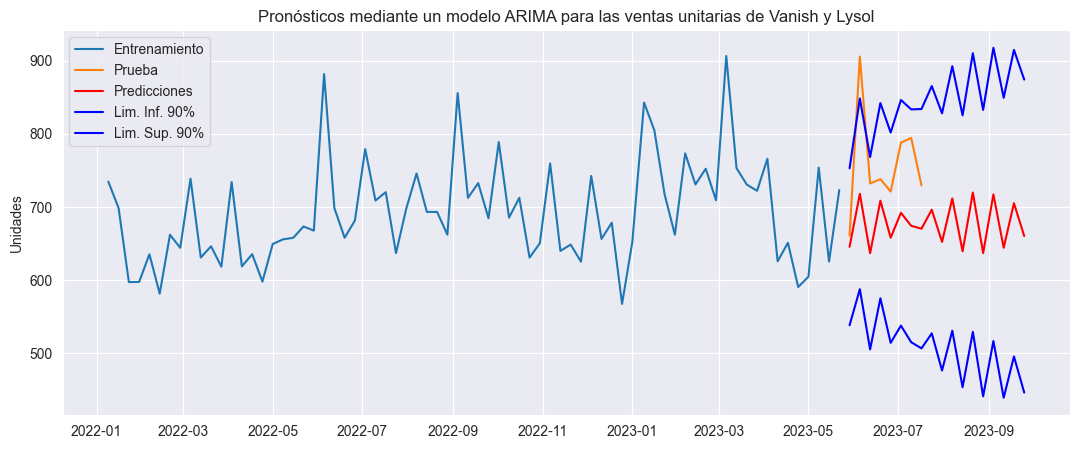

In [23]:
plt.figure(figsize=(13,5))
plt.grid()
plt.plot(sales_train, label = "Entrenamiento")
plt.plot(sales_test, label = "Prueba")
plt.plot(sales_fcast['Predicciones'], label = "Predicciones", color = "red")
plt.plot(sales_fcast['lower'], label = "Lim. Inf. 90%", color = "blue")
plt.plot(sales_fcast['upper'], label = "Lim. Sup. 90%", color = "blue")
plt.legend(loc="best")
plt.title("Pronósticos mediante un modelo ARIMA para las ventas unitarias de Vanish y Lysol")
plt.ylabel('Unidades')
plt.grid(True)
plt.show()

## Calculando indicadores de bondad del ajuste para el conjunto de prueba

También fueron calculados los indicadores de bondad del ajuste, para evaluar analíticamente a nuestro modelo.

In [24]:
acumulador1 = 0
acumulador2 = 0
n_test = len(sales_test)

for contador in range(n_test):
    acumulador1 = acumulador1 + (float(sales_test.iloc[contador]) - float(sales_fcast['Predicciones'].iloc[contador])) ** 2
    acumulador2 = acumulador2 + np.abs((float(sales_test.iloc[contador]) - float(sales_fcast['Predicciones'].iloc[contador])) / float(sales_test.iloc[contador]))

mse = acumulador1 / n_test
rmse = np.round(np.sqrt(mse), 2)
mape = np.round((acumulador2 / n_test) * 100, 2)
print("RMSE =", rmse, "\nMAPE = ", mape, "%")

RMSE = 97.73 
MAPE =  10.52 %


Observando la gráfica, podemos ver que las predicciones replican las fluctuaciones presentes en los datos, mostrando también un breve momento en el que se estabilizan un poco, para volver a fluctuar como se ven en los datos reales. Ahora bien, los picos de las fluctuaciones no son tan pronunciados como deberían, alejándose de los datos reales de prueba. Esto último se ve reflejado en los indicadores de la bondad del ajuste, pues se obtuvo un RMSE de 97.7 y un MAPE de 10.52%, indicando que, en promedio, el modelo tiene un error de 97.7 unidades o un error del 10.5%. Si bien este error es algo significativo, se logró entrenar un modelo que puede estimar el comportamiento de los datos y, en conjunto con los intervalos de confianza, se pueden estimar con rangos de unidades totales las fluctuaciones de las ventas.